<a href="https://colab.research.google.com/github/youkjang/gefs_temperature_spread_error/blob/main/notebooks/02_multidate_spread_skill_ratio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEFS Temperature Spread–Skill Ratio Across Multiple Dates

**Goal:** Extend the single-case GEFS spread-error analysis to multiple initialization dates.

Main question:

> Is GEFS ensemble spread statistically consistent with actual forecast error across multiple initialization dates?

This notebook computes ensemble spread, RMSE, MAE, bias, and spread-skill ratio.

## 1. Install package from GitHub repository


- After updating my GitHub source files, uninstall the old installed verison

In [1]:
#!pip uninstall -y gefs_temperature_spread_error

In [2]:
# %cd /content/gefs-temperature-spread-error
# !git pull
# !pip install -e .

In [3]:
# !rm -rf data/gefs
# !rm -rf data/gfs

In [4]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

In [5]:
!pip install git+https://github.com/youkjang/gefs_temperature_spread_error.git

  Cloning https://github.com/youkjang/gefs_temperature_spread_error.git to /tmp/pip-req-build-zwoke34f
  Running command git clone --filter=blob:none --quiet https://github.com/youkjang/gefs_temperature_spread_error.git /tmp/pip-req-build-zwoke34f
  Resolved https://github.com/youkjang/gefs_temperature_spread_error.git to commit 78d83894d6ef576fa9202d9b999abd70ef34acdf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Import packages and project modules

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [7]:
from gefs_spread_error.config import ProjectConfig

from gefs_spread_error.data_access import (
    load_gefs_member_t2m,
    load_gfs_analysis_t2m,
)

In [8]:
from gefs_spread_error.verification import (
    stack_members,
    ensemble_mean,
    ensemble_spread,
    forecast_error,
    rmse,
    mean_absolute_error,
    bias,
    area_weighted_mean,
    spread_skill_ratio,
)

In [9]:
from gefs_spread_error.plotting import (
    plot_mean_spread_rmse_by_lead,
    plot_spread_skill_ratio_by_lead,
    plot_spread_skill_boxplot,
)

## 3. Set configuration

Start small in Google Colab. Later you can add more dates, more lead times, and more ensemble members.

In [10]:
config = ProjectConfig()

config.init_hour = "00"

config.init_dates = [
    "20260505",
    "20260510",
    "20260515",
    "20260520",
    "20260525",
]

config.forecast_hours = [24, 48, 72, 96]

# Start with 10 members for Colab.
config.members = [f"gep{i:02d}" for i in range(1, 11)]

config

ProjectConfig(init_date='20240115', init_hour='00', init_dates=['20260505', '20260510', '20260515', '20260520', '20260525'], forecast_hours=[24, 48, 72, 96], members=['gep01', 'gep02', 'gep03', 'gep04', 'gep05', 'gep06', 'gep07', 'gep08', 'gep09', 'gep10'], lon_min=230.0, lon_max=300.0, lat_min=20.0, lat_max=55.0, variable='t2m', gefs_bucket='noaa-gefs-pds', gfs_bucket='noaa-gfs-bdp-pds')

In [11]:
config.init_date


'20240115'

In [12]:
config.init_dates

['20260505', '20260510', '20260515', '20260520', '20260525']

## 4. Run multi-date spread-skill analysis

For a quick test, use fewer dates, fewer lead times, and fewer members:

```python
config.init_dates = ["20240115"]
config.forecast_hours = [24, 48]
config.members = [f"gep{i:02d}" for i in range(1, 4)]
```

In [13]:
for init_date in config.init_dates:
    print(f"Processing init={init_date} {config.init_hour}Z")

Processing init=20260505 00Z
Processing init=20260510 00Z
Processing init=20260515 00Z
Processing init=20260520 00Z
Processing init=20260525 00Z


In [14]:
rows = []

for init_date in config.init_dates:
    for fhr in config.forecast_hours:
        print(f"Processing init={init_date} {config.init_hour}Z, f{fhr:03d}")

        member_arrays = []

        for member in config.members:
            print(f"  loading {member}")
            da = load_gefs_member_t2m(
                config,
                member=member,
                fhr=fhr,
                init_date=init_date,
                init_hour=config.init_hour,
            )
            member_arrays.append(da)

        ens = stack_members(member_arrays)
        ens_mean = ensemble_mean(ens)
        spread = ensemble_spread(ens)

        analysis = load_gfs_analysis_t2m(
            config,
            fhr=fhr,
            init_date=init_date,
            init_hour=config.init_hour,
        )

        error = forecast_error(ens_mean, analysis)

        spread_mean = area_weighted_mean(spread)
        rmse_value = rmse(error, weighted=True)
        mae_value = mean_absolute_error(error, weighted=True)
        bias_value = bias(error, weighted=True)
        ssr_value = spread_skill_ratio(spread_mean, rmse_value)

        rows.append(
            {
                "init_date": init_date,
                "init_hour": config.init_hour,
                "forecast_hour": fhr,
                "n_members": len(config.members),
                "spread_mean": spread_mean,
                "rmse": rmse_value,
                "mae": mae_value,
                "bias": bias_value,
                "spread_skill_ratio": ssr_value,
            }
        )

results_df = pd.DataFrame(rows)
results_df

Processing init=20260505 00Z, f024
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing init=20260505 00Z, f048
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing init=20260505 00Z, f072
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing init=20260505 00Z, f096
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing init=20260510 00Z, f024
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing init=20260510 

,init_date,init_hour,forecast_hour,n_members,spread_mean,rmse,mae,bias,spread_skill_ratio
0,20260505,00,24,10,0.710800,1.102587,0.720108,0.138310,0.644666
1,20260505,00,48,10,0.833896,1.541299,0.988707,0.277480,0.541035
2,20260505,00,72,10,0.945143,1.624488,1.170848,0.200130,0.581810
3,20260505,00,96,10,1.006820,1.696229,1.186877,0.269763,0.593564
4,20260510,00,24,10,0.622969,1.210313,0.721132,0.254864,0.514717
5,20260510,00,48,10,0.800314,1.306168,0.877436,0.209809,0.612719
6,20260510,00,72,10,0.952014,1.576362,1.098087,0.465803,0.603931
7,20260510,00,96,10,1.305967,3.126560,1.698108,1.009584,0.417701
8,20260515,00,24,10,0.642655,1.264349,0.731770,0.283352,0.508289
9,20260515,00,48,10,0.879605,1.419937,0.893272,0.327527,0.619467


## 5. Save raw results

In [15]:
output_dir = Path("figures/multidate")
output_dir.mkdir(parents=True, exist_ok=True)

raw_csv = output_dir / "multidate_spread_skill_raw_results.csv"
results_df.to_csv(raw_csv, index=False)

print(f"Saved: {raw_csv}")
results_df

Saved: figures/multidate/multidate_spread_skill_raw_results.csv


,init_date,init_hour,forecast_hour,n_members,spread_mean,rmse,mae,bias,spread_skill_ratio
0,20260505,00,24,10,0.710800,1.102587,0.720108,0.138310,0.644666
1,20260505,00,48,10,0.833896,1.541299,0.988707,0.277480,0.541035
2,20260505,00,72,10,0.945143,1.624488,1.170848,0.200130,0.581810
3,20260505,00,96,10,1.006820,1.696229,1.186877,0.269763,0.593564
4,20260510,00,24,10,0.622969,1.210313,0.721132,0.254864,0.514717
5,20260510,00,48,10,0.800314,1.306168,0.877436,0.209809,0.612719
6,20260510,00,72,10,0.952014,1.576362,1.098087,0.465803,0.603931
7,20260510,00,96,10,1.305967,3.126560,1.698108,1.009584,0.417701
8,20260515,00,24,10,0.642655,1.264349,0.731770,0.283352,0.508289
9,20260515,00,48,10,0.879605,1.419937,0.893272,0.327527,0.619467


## 6. Summarize by forecast lead time

In [16]:
summary_by_lead = (
    results_df
    .groupby("forecast_hour", as_index=False)
    .agg(
        spread_mean=("spread_mean", "mean"),
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        bias=("bias", "mean"),
        spread_skill_ratio=("spread_skill_ratio", "mean"),
        n_cases=("init_date", "count"),
    )
)

summary_csv = output_dir / "multidate_spread_skill_summary_by_lead.csv"
summary_by_lead.to_csv(summary_csv, index=False)

print(f"Saved: {summary_csv}")
summary_by_lead

Saved: figures/multidate/multidate_spread_skill_summary_by_lead.csv


,forecast_hour,spread_mean,rmse,mae,bias,spread_skill_ratio,n_cases
0,24,0.663722,1.274028,0.771693,0.277134,0.525877,5
1,48,0.866013,1.542915,0.985810,0.341408,0.565290,5
2,72,1.015829,1.740314,1.145505,0.330697,0.584096,5
3,96,1.215971,2.214108,1.370390,0.577991,0.565147,5


## 7. Plot mean spread and RMSE by lead time
###Each Initial Date

Saved: figures/multidate/3.spread_rmse_by_lead_all_dates.png


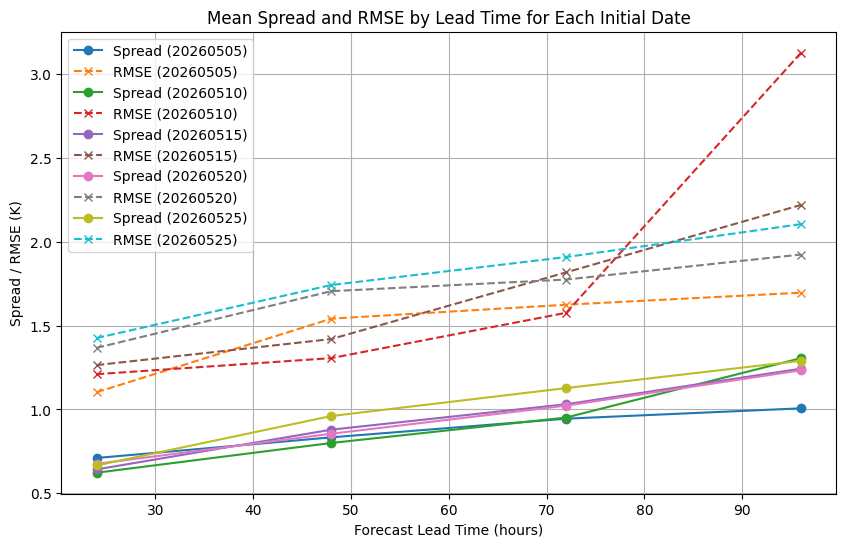

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for init_date in config.init_dates:
    df_date = results_df[results_df['init_date'] == init_date]
    ax.plot(df_date['forecast_hour'], df_date['spread_mean'], marker='o', linestyle='-', label=f'Spread ({init_date})')
    ax.plot(df_date['forecast_hour'], df_date['rmse'], marker='x', linestyle='--', label=f'RMSE ({init_date})')

ax.set_title('Mean Spread and RMSE by Lead Time for Each Initial Date')
ax.set_xlabel('Forecast Lead Time (hours)')
ax.set_ylabel('Spread / RMSE (K)')
ax.legend()
ax.grid(True)

output_path = output_dir / "3.spread_rmse_by_lead_all_dates.png"
plt.savefig(output_path)
print(f"Saved: {output_path}")

plt.show()

### Multi-Date Mean
- Spread and RMSE change with lead time.

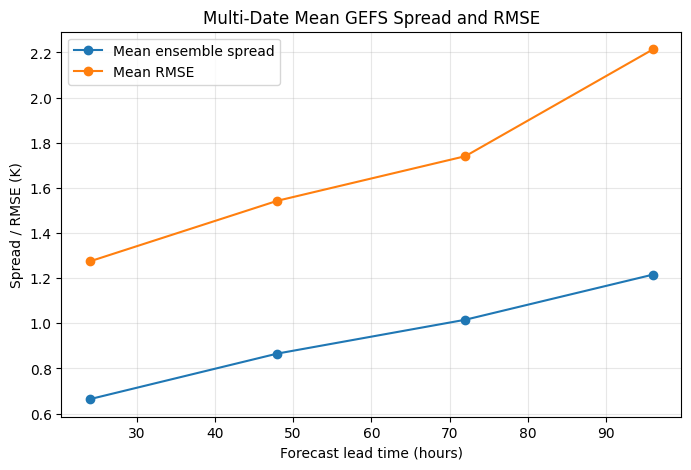

In [18]:
fig, ax = plot_mean_spread_rmse_by_lead(
    summary_by_lead,
    output_path=output_dir / "4.mean_spread_rmse_by_lead.png",
)

plt.show()

## 8. Plot spread-skill ratio by lead
- Spread-Skill ratio = spread / RMSE
- ensemble spread < RMSE: The GEFS 2-m temperature ensemble is underdispersive in this sample.
- The ensemble members are too close to each other compared with the size of the forecast errors.

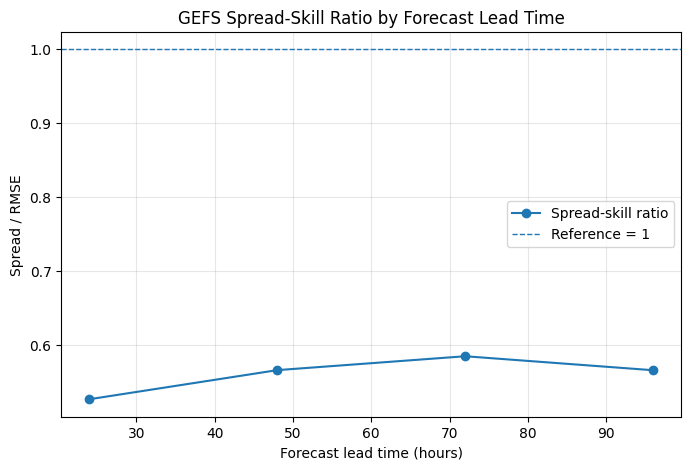

In [19]:
fig, ax = plot_spread_skill_ratio_by_lead(
    summary_by_lead,
    output_path=output_dir / "5.spread_skill_ratio_by_lead.png",
)

plt.show()

## 9. Boxplot of spread-skill ratio
- Consistant underdispersion results
- Some spread at f048 and f096
- Outlier cases: f024 and f096

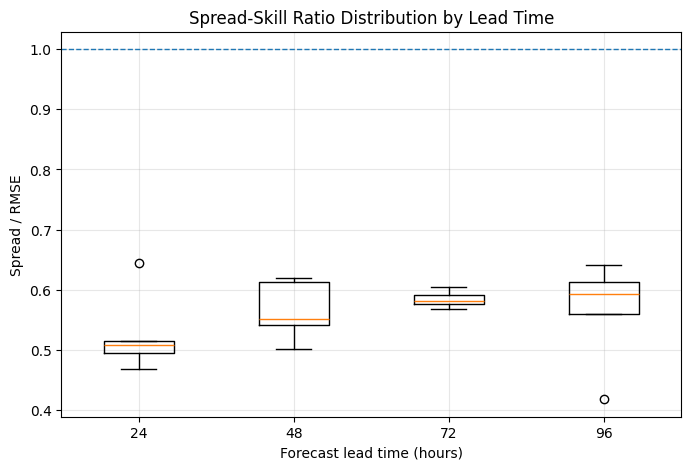

In [20]:
fig, ax = plot_spread_skill_boxplot(
    results_df,
    output_path=output_dir / "6.spread_skill_ratio_boxplot.png",
)

plt.show()

## 10. Basic interpretation helper

In [21]:
mean_ssr = summary_by_lead["spread_skill_ratio"].mean()

print(f"Mean spread-skill ratio across lead times: {mean_ssr:.2f}")

if mean_ssr < 0.8:
    print("Interpretation: GEFS spread is much smaller than RMSE. This suggests possible underdispersion.")
elif mean_ssr <= 1.2:
    print("Interpretation: GEFS spread and RMSE are reasonably close on average.")
else:
    print("Interpretation: GEFS spread is larger than RMSE. This suggests possible overdispersion.")

Mean spread-skill ratio across lead times: 0.56
Interpretation: GEFS spread is much smaller than RMSE. This suggests possible underdispersion.


## 11. Suggested conclusion

This notebook extended a single-case GEFS spread-error analysis to multiple initialization dates. For each initialization date and forecast lead time, GEFS ensemble spread was compared with RMSE against GFS analysis over CONUS.

The mean spread-skill ratio can be used as a simple diagnostic of ensemble dispersion. A value below 1 suggests that ensemble spread is smaller than the realized forecast error, indicating possible underdispersion.